In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import cv2
from PIL import Image, UnidentifiedImageError, ImageEnhance, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import shutil
from tqdm import tqdm
import random
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Model: EfficientNetB0

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 16839 files belonging to 22 classes.
Found 3598 files belonging to 22 classes.
Found 3634 files belonging to 22 classes.


In [3]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print(num_classes)

['Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner', 'Cashew red rust', 'Cassava bacterial blight', 'Cassava brown spot', 'Cassava green mite', 'Cassava healthy', 'Cassava mosaic', 'Maize fall armyworm', 'Maize grasshoper', 'Maize healthy', 'Maize leaf beetle', 'Maize leaf blight', 'Maize leaf spot', 'Maize streak virus', 'Tomato healthy', 'Tomato leaf blight', 'Tomato leaf curl', 'Tomato septoria leaf spot', 'Tomato verticulium wilt']
22


In [4]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [7]:
pretrained_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
    classes=num_classes
)   

pretrained_model.trainable = True  # Freeze layer-layer EfficientNetB0-nya

for layer in pretrained_model.layers[:-50]:
    layer.trainable = False

16705208/16705208 [==============================] - 3s 0us/step


In [8]:
model = models.Sequential([
    pretrained_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [9]:
pretrained_model.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_1 (Rescaling)        (None, 224, 224, 3)  0           ['input_2[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 224, 224, 3)  7          ['rescaling_1[0][0]']            
 )                                                                                                
                                                                                     

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 22)                11286     
                                                                 
Total params: 4,716,729
Trainable params: 3,194,022
Non-trainable params: 1,522,707
______________________________________

In [11]:
train_labels_list = []

for _, labels in train_ds.unbatch():
    train_labels_list.append(int(labels.numpy()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_list
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 0.6325694966190833, 1: 2.7934638354346384, 2: 0.7998005129666572, 3: 0.7939928328932478, 4: 0.6508580705009277, 5: 0.42194547459156057, 6: 0.746740576496674, 7: 1.079561482241313, 8: 0.9166575939031029, 9: 0.9838163122224819, 10: 3.865702479338843, 11: 1.62507237984945, 12: 5.390204865556978, 13: 1.1721425588194347, 14: 1.394187779433681, 15: 1.0660293745251963, 16: 1.194085945255992, 17: 2.3623737373737375, 18: 0.8514005460612802, 19: 2.1440030557677616, 20: 0.47689039932030586, 21: 1.4174242424242425}


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
    # callbacks=[early_stop]
)

Epoch 1/20
527/527 [==============================] - 425s 772ms/step - loss: 0.9930 - accuracy: 0.6717 - val_loss: 0.5052 - val_accuracy: 0.8043
Epoch 2/20
527/527 [==============================] - 446s 822ms/step - loss: 0.4175 - accuracy: 0.8300 - val_loss: 0.3700 - val_accuracy: 0.8583
Epoch 3/20
527/527 [==============================] - 438s 805ms/step - loss: 0.3111 - accuracy: 0.8697 - val_loss: 0.3365 - val_accuracy: 0.8769
Epoch 4/20
527/527 [==============================] - 1239s 2s/step - loss: 0.2422 - accuracy: 0.8989 - val_loss: 0.3269 - val_accuracy: 0.8819
Epoch 5/20
527/527 [==============================] - 1359s 3s/step - loss: 0.1887 - accuracy: 0.9186 - val_loss: 0.3051 - val_accuracy: 0.8963
Epoch 6/20
527/527 [==============================] - 995s 2s/step - loss: 0.1515 - accuracy: 0.9334 - val_loss: 0.3160 - val_accuracy: 0.8947
Epoch 7/20
527/527 [==============================] - 443s 814ms/step - loss: 0.1224 - accuracy: 0.9483 - val_loss: 0.3058 - val_ac

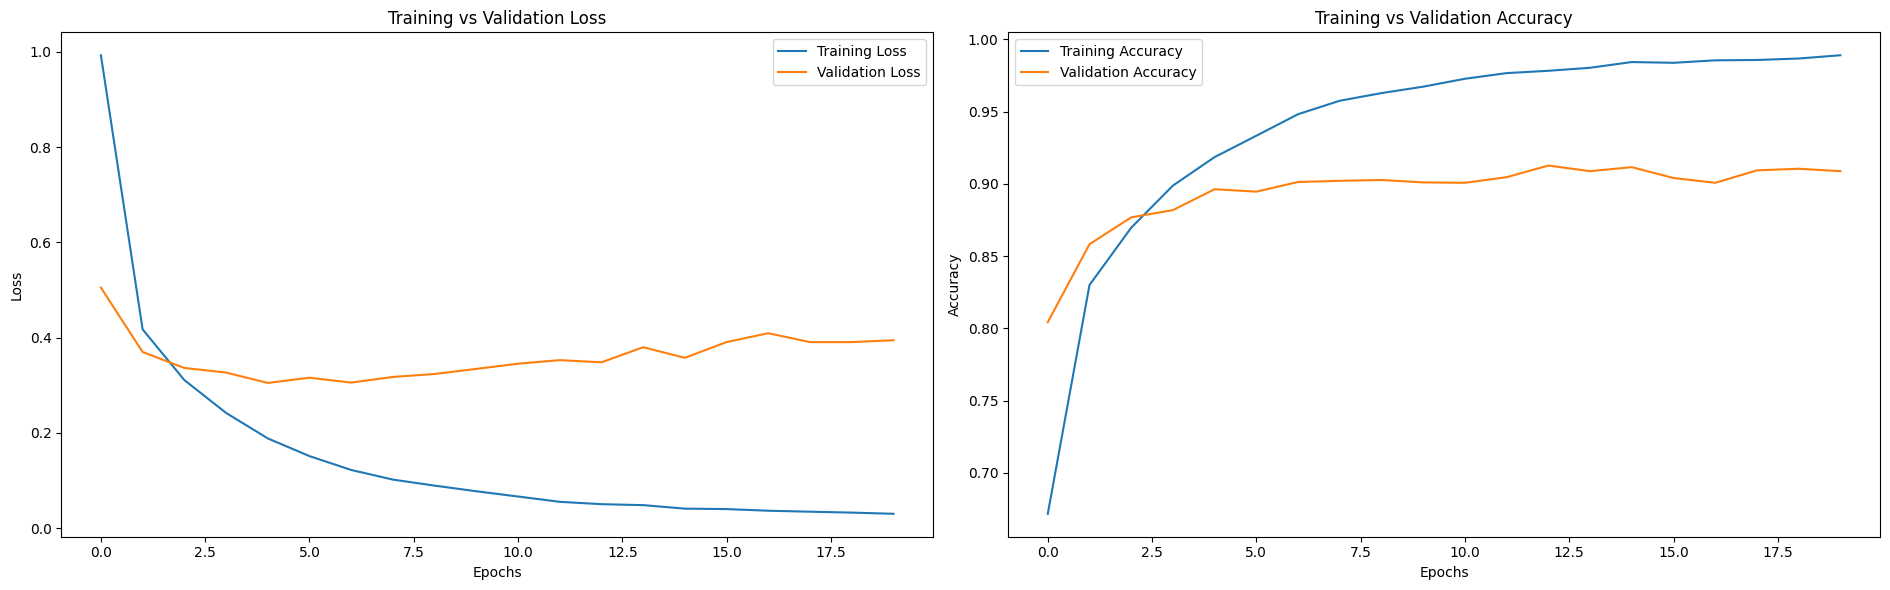

In [14]:
plt.figure(figsize=(19, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

114/114 [==============================] - 205s 2s/step - loss: 0.4045 - accuracy: 0.9106
Test Accuracy: 0.9105668663978577
Test Loss: 0.4044676721096039


In [16]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 [==============================] - 5s 5s/step


In [17]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                           precision    recall  f1-score   support

       Cashew anthracnose       0.95      0.93      0.94       260
           Cashew gumosis       1.00      1.00      1.00        60
           Cashew healthy       0.99      0.98      0.98       206
        Cashew leaf miner       0.92      0.95      0.93       208
          Cashew red rust       0.98      0.98      0.98       253
 Cassava bacterial blight       0.94      0.95      0.95       390
       Cassava brown spot       0.95      0.93      0.94       221
       Cassava green mite       0.91      0.96      0.93       153
          Cassava healthy       0.99      0.95      0.97       180
           Cassava mosaic       0.97      0.95      0.96       168
      Maize fall armyworm       0.90      0.98      0.93        44
         Maize grasshoper       0.99      0.98      0.99       102
            Maize healthy       0.90      0.87      0.89        31
        Maize leaf beetle       0.99  

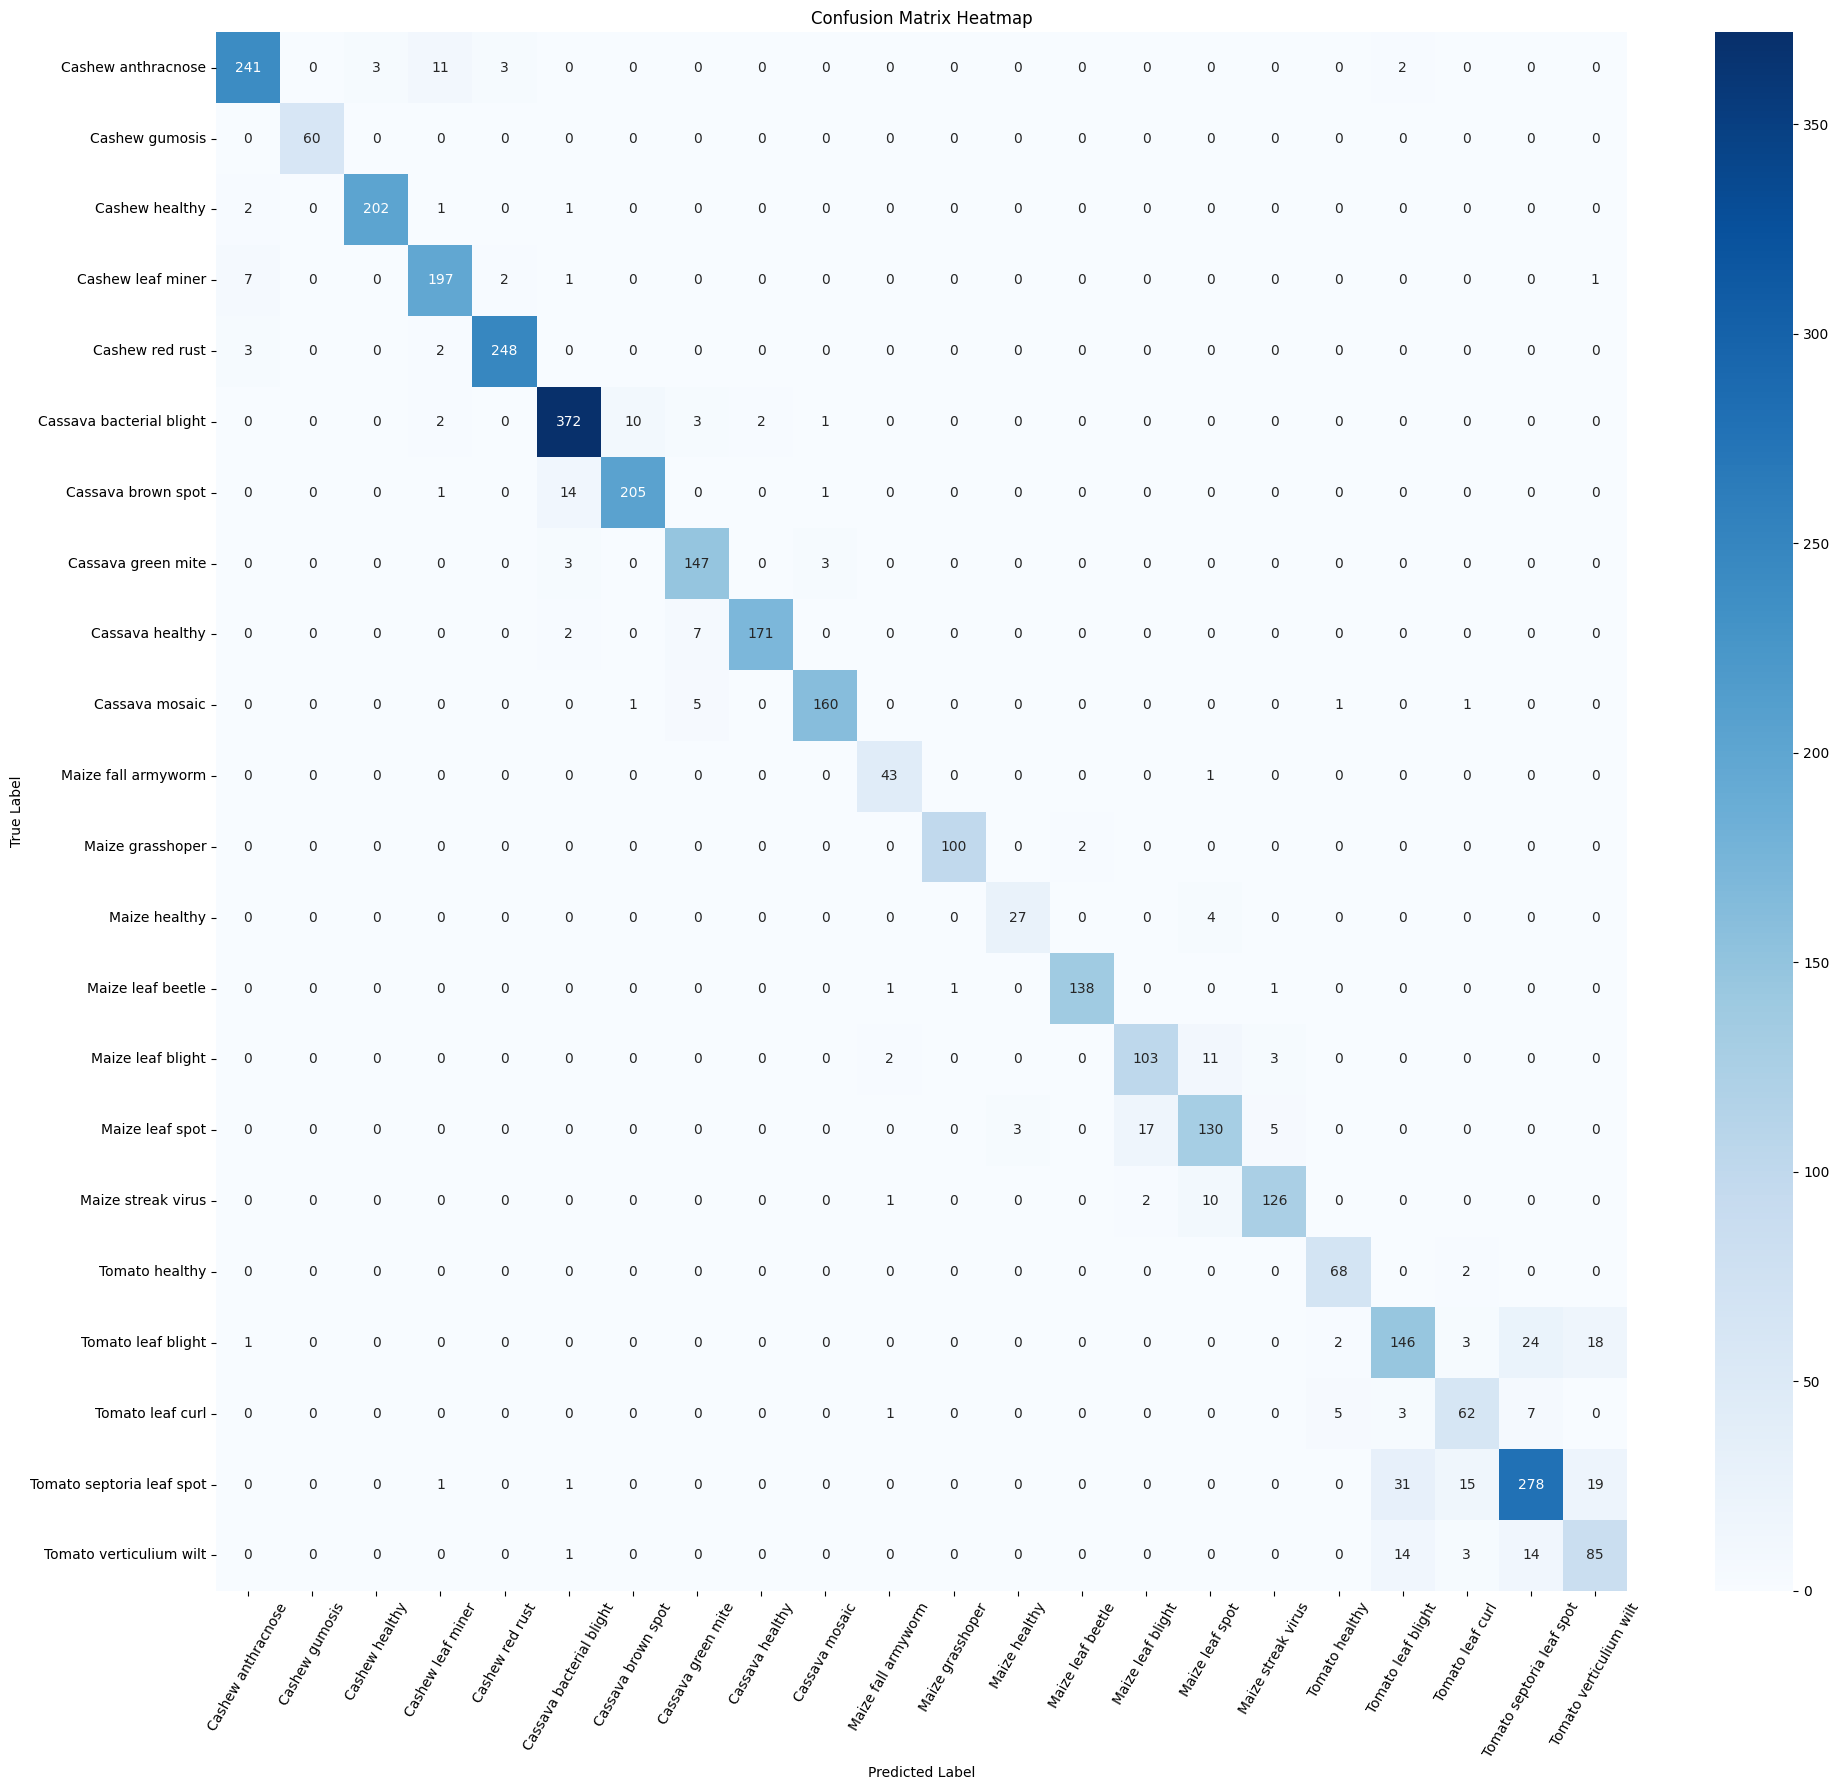

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# SAVE MODEL

In [21]:
model.save_weights("efficientnetb0_model_weights.h5")
print("Model saved...")

Model saved...


### Test Load Model

In [22]:
def build_model(num_classes, freeze_layers=-50):
    pretrained_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        classes=num_classes
    )

    pretrained_model.trainable = True

    # Freeze layer awal
    for layer in pretrained_model.layers[:freeze_layers]:
        layer.trainable = False

    model = models.Sequential([
        pretrained_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    
    return model

In [23]:
loaded_model = build_model(num_classes, freeze_layers=-50)

loaded_model.load_weights("efficientnetb0_model_weights.h5")
print("Weights loaded successfully!")

Weights loaded successfully!


In [24]:
loaded_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
test_loss, test_acc = loaded_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

114/114 [==============================] - 57s 487ms/step - loss: 0.4045 - accuracy: 0.9106
Test Loss: 0.40446752309799194
Test Accuracy: 0.9105668663978577
